In [1]:
import numpy as np
import os

# Параметры модели
K = 32          # число крупномасштабных переменных
J = 10          # число мелкомасштабных переменных на одну крупную
F = 10.0
h = 1.0
b = 10.0
c = 10.0
coupling = h * c / b   # = 1.0

# Параметры интегрирования
dt = 5e-4               # шаг RK4
spinup_steps = round(10 / dt)   # прогрев (10 единиц времени)
save_every = round(0.1 / dt)       # шаг выборки = 0.1
samples_per_traj = 200
n_traj = 20

In [2]:
def M(s):
    X = s[:K]
    Y = s[K:].reshape(K, J)

    # Соседи X
    Xm1 = np.roll(X,  1)   # X_{k-1}
    Xm2 = np.roll(X,  2)   # X_{k-2}
    Xp1 = np.roll(X, -1)   # X_{k+1}

    # Крупный масштаб
    dX = -Xm1 * (Xm2 - Xp1) - X + F - coupling * Y.sum(axis=1)

    # Соседи Y по быстрому индексу j
    Yp1 = np.roll(Y, -1, axis=1)   # Y_{j+1}
    Yp2 = np.roll(Y, -2, axis=1)   # Y_{j+2}
    Ym1 = np.roll(Y,  1, axis=1)   # Y_{j-1}

    # Мелкий масштаб
    dY = -c * b * Yp1 * (Yp2 - Ym1) - c * Y + coupling * X[:, None]

    return np.concatenate([dX, dY.ravel()])

In [3]:
# Runge-Kutta-4
def RK4(s, dt):
  k1 = M(s)
  k2 = M(s + .5*dt*k1)
  k3 = M(s + .5*dt*k2)
  k4 = M(s + dt*k3)

  return s + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

In [4]:
# Генерация
rng = np.random.default_rng(37)

X_list, B_list = [], []

for n in range(n_traj):
    # Начальные условия: X около F с малым шумом, Y = 0
    X0 = F + 0.1 * rng.standard_normal(K)
    Y0 = np.zeros(K * J)
    state = np.concatenate([X0, Y0])

    # Прогрев выводим систему на аттрактор
    for _ in range(spinup_steps):
        state = RK4(state, dt)

    # Сбор данных
    for s in range(samples_per_traj):
        for _ in range(save_every):
            state = RK4(state, dt)

        X = state[:K].copy()
        Y = state[K:].reshape(K, J)
        B = -coupling * Y.sum(axis=1)   # подсеточный член B_k

        X_list.append(X)
        B_list.append(B)

    print(f"Траектория {n + 1}/{n_traj} готова")

X_data = np.array(X_list)   # (n_samples, K)
B_data = np.array(B_list)   # (n_samples, K)

print("Форма X_data:", X_data.shape)
print("Форма B_data:", B_data.shape)
print("Среднее X:", X_data.mean(axis=0).mean())
print("Стд X:",     X_data.std(axis=0).mean())
print("Среднее B:", B_data.mean(axis=0).mean())
print("Стд B:",     B_data.std(axis=0).mean())

# Сохранение
os.makedirs("data", exist_ok=True)
np.savez(
    "data/l96_data.npz",
    X=X_data, B=B_data,
    K=K, J=J, F=F, h=h, b=b, c=c,
    dt_save=save_every * dt,
)
print("Сохранено в data/l96_data.npz")

Траектория 1/20 готова
Траектория 2/20 готова
Траектория 3/20 готова
Траектория 4/20 готова
Траектория 5/20 готова
Траектория 6/20 готова
Траектория 7/20 готова
Траектория 8/20 готова
Траектория 9/20 готова
Траектория 10/20 готова
Траектория 11/20 готова
Траектория 12/20 готова
Траектория 13/20 готова
Траектория 14/20 готова
Траектория 15/20 готова
Траектория 16/20 готова
Траектория 17/20 готова
Траектория 18/20 готова
Траектория 19/20 готова
Траектория 20/20 готова
Форма X_data: (4000, 32)
Форма B_data: (4000, 32)
Среднее X: 2.034606686249951
Стд X: 2.5977756950389628
Среднее B: -2.0350407135408473
Стд B: 2.3079062696457653
Сохранено в data/l96_data.npz


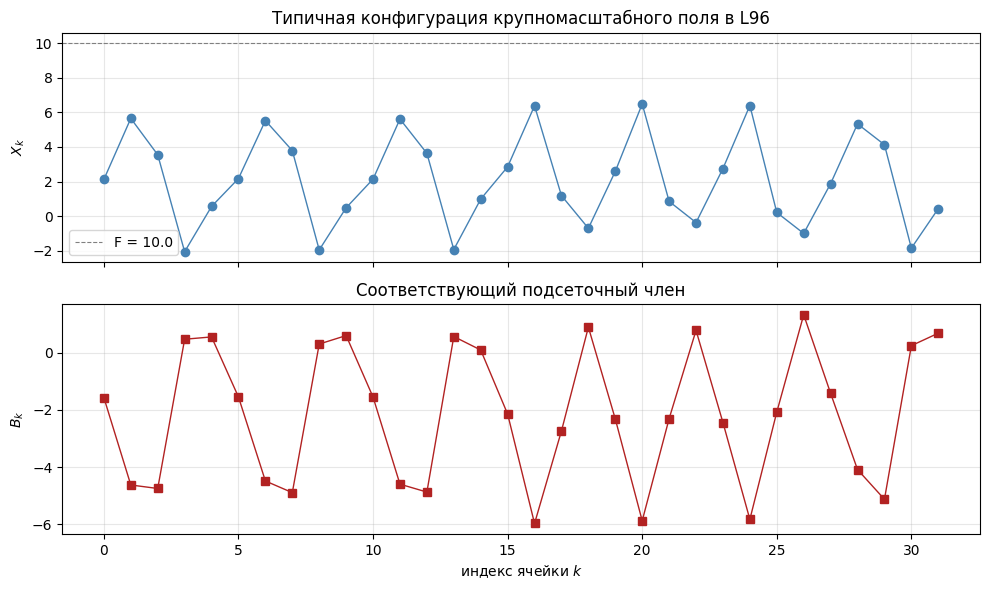

In [5]:
# =============================================================
# Визуализация типичной конфигурации поля X
# =============================================================
import matplotlib.pyplot as plt

# Возьмём один снимок из данных
snapshot = X_data[100]   # (K,)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Верхняя панель: поле X_k
axes[0].plot(np.arange(K), snapshot, marker="o", lw=1.0, color="steelblue")
axes[0].axhline(F, color="gray", ls="--", lw=0.8, label=f"F = {F}")
axes[0].set_ylabel(r"$X_k$")
axes[0].set_title("Типичная конфигурация крупномасштабного поля в L96")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Нижняя панель: соответствующий подсеточный член B_k
B_snapshot = B_data[100]
axes[1].plot(np.arange(K), B_snapshot, marker="s", lw=1.0, color="firebrick")
axes[1].set_xlabel("индекс ячейки $k$")
axes[1].set_ylabel(r"$B_k$")
axes[1].set_title("Соответствующий подсеточный член")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("l96_field.png", dpi=150)
plt.show()